# **Exploratory Data Analysis**

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dataset
data = pd.read_csv("HousingData.csv")

In [3]:
#Basic Info
print("First 5 rows:")
print(data.head())
print("-" * 120)

print("Dataset Info:")
data.info()
print("-" * 120)

print("Statistical Summary:")
print(data.describe())

First 5 rows:
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90    NaN  36.2  
------------------------------------------------------------------------------------------------------------------------
Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN     

In [4]:
#Data Cleaning
#Check Missing Values
print("Missing values before cleaning:")
print(data.isnull().sum())
print("-" * 120)

#Handle Missing Values
data = data.fillna(data.mean())
print("Missing values after filling:")
print(data.isnull().sum())
print("-" * 120)

#Remove Duplicate Rows
print(f"Shape Before Removing Duplicates = {data.shape}")
data = data.drop_duplicates()
print(f"Shape After Removing Duplicates = {data.shape}")
print("-" * 120)

#Handle Outliers (Simple Method)
# Using IQR method
for col in data.columns:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    data = data[(data[col] >= lower) & (data[col] <= upper)]

#Final Check
print("Final shape of dataset:", data.shape)
print("Cleaned Data Preview:")
print(data.head())

Missing values before cleaning:
CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64
------------------------------------------------------------------------------------------------------------------------
Missing values after filling:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64
------------------------------------------------------------------------------------------------------------------------
Shape Before Removing Duplicates = (506, 14)
Shape After Removing Duplicates = (506, 14)
------------------------------------------------------------------------------------------------------------------------
Final shape of dataset: (206, 14)
Cleaned Data Preview:
       CRIM    ZN  INDUS  

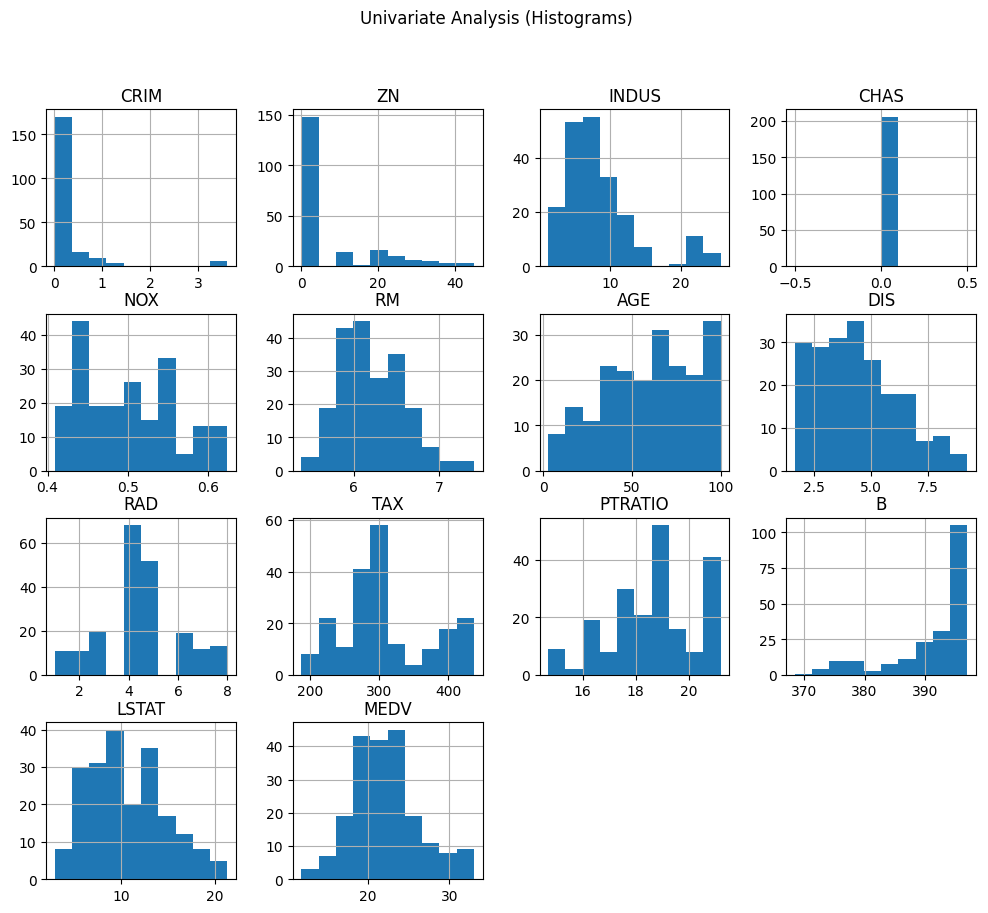

In [5]:
#Univariate Analysis
# Histogram for all columns
data.hist(figsize=(12, 10))
plt.suptitle("Univariate Analysis (Histograms)")
plt.show()

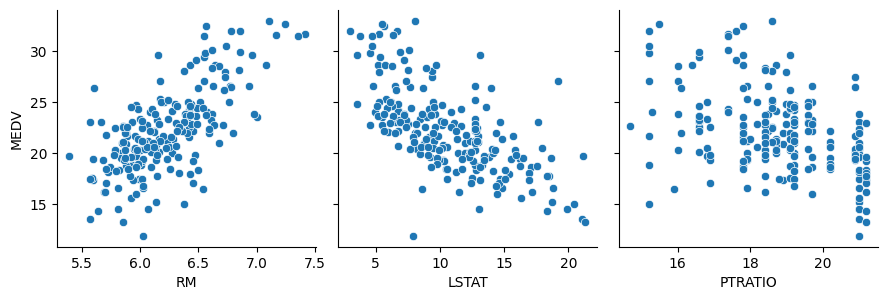

In [6]:
#Bivariate Analysis
sns.pairplot(data, x_vars=["RM", "LSTAT", "PTRATIO"], y_vars="MEDV", height=3)
plt.show()

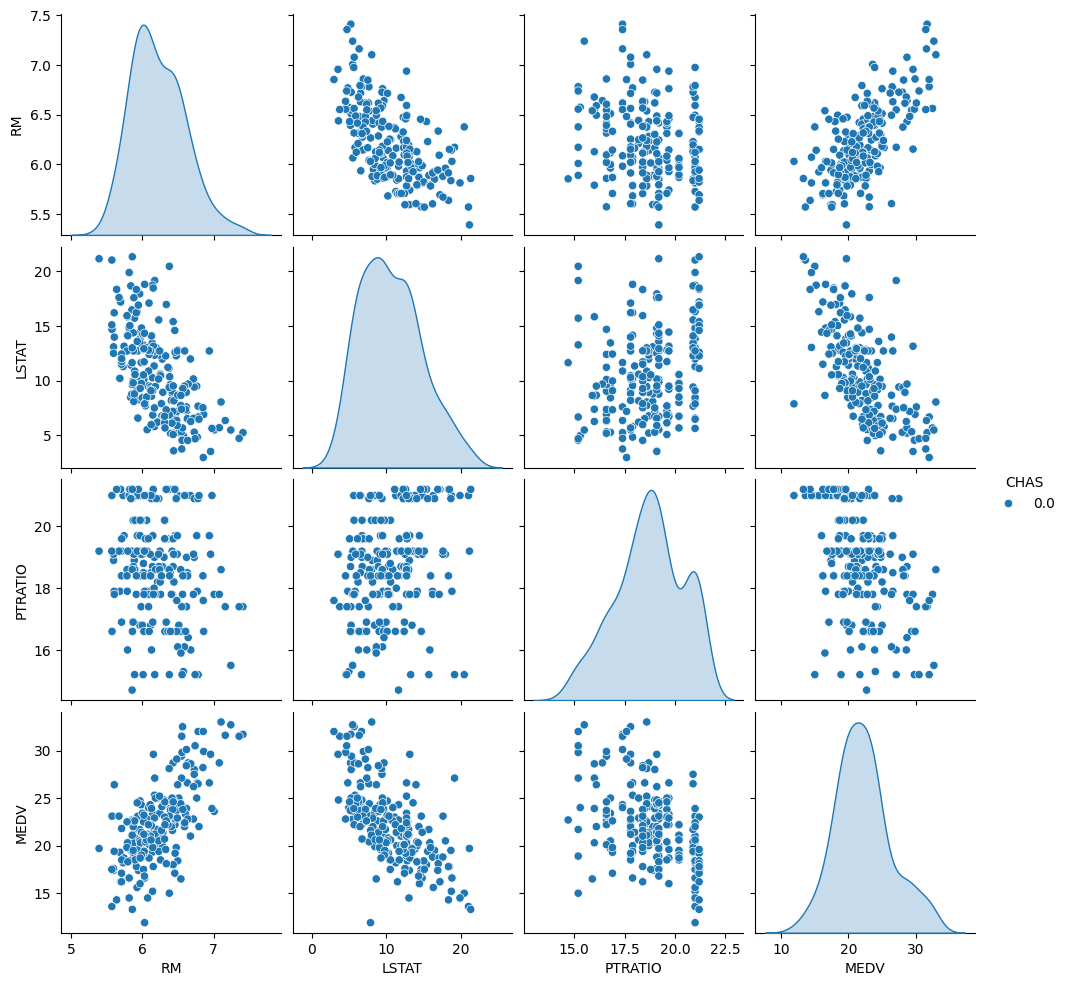

In [7]:
#Multivariate Analysis
cols = ["RM", "LSTAT", "PTRATIO", "MEDV", "CHAS"]
sns.pairplot(data[cols], hue="CHAS")
plt.show()

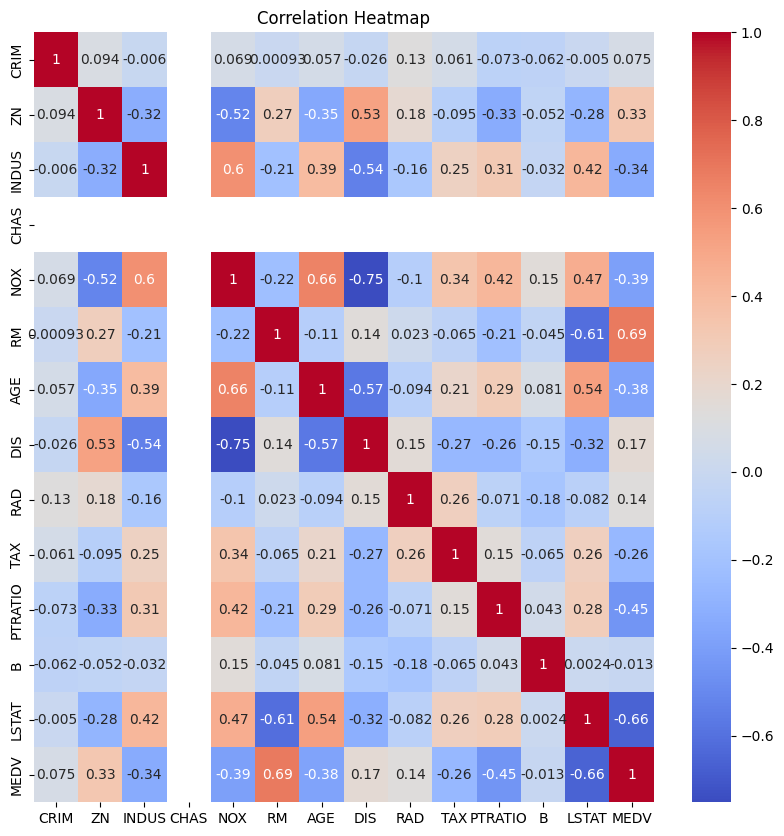

In [8]:
#Corrleation Matrix
corr = data.corr()
plt.figure(figsize=(10, 10))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# **Training and Testing**

In [9]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

#Features and target
X = data.drop("MEDV", axis=1)
y = data["MEDV"]

#Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Model (Linear Regression)
model = LinearRegression()

# Training model
model.fit(X_train, y_train)

#Testing Model
y_pred = model.predict(X_test)

#Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("MSE:", mse)
print("R2 Score:", r2)
print(f"Accuracy: {r2 * 100:.2f}%")

MSE: 5.091297909815106
R2 Score: 0.7451999489065348
Accuracy: 74.52%


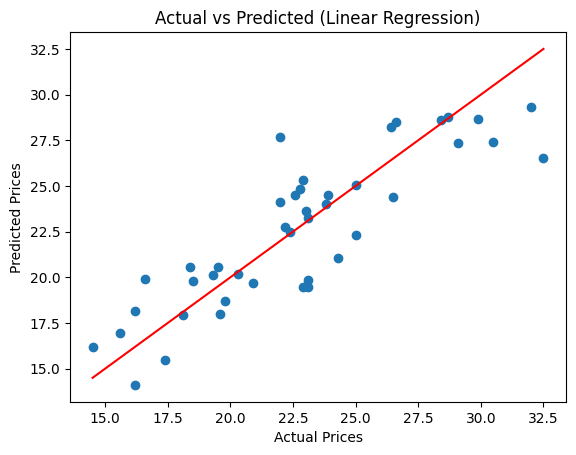

In [10]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)

# Line of perfect prediction
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted (Linear Regression)")
plt.show()